# Paso 1: Lectura del conjunto de datos procesado

In [1]:
import pandas as pd
#Cargamos el conjunto de datos 
data = pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep= ";")
#imprimimos los 5 primeras lineas
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
#Tamanio de la data
data.shape
#Nombres de columnas
data.columns
#Todo el resto de la info
data.info()

data.isnull().sum()
data.duplicated().sum()
data["y"].value_counts()
data["y"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [3]:
# Resumen estadistico de variables numericas
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [4]:
# Resumen de variables categoricas
data.describe(include="object")

/var/folders/5b/yfj9mmxn2919wjkjy_npmqvm0000gn/T/ipykernel_88429/876999345.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object")


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [5]:
# Duplicados
data.duplicated().sum()

np.int64(12)

In [6]:
data = data.drop_duplicates()
data.shape

(41176, 21)

# Paso 2: EDA

In [7]:
#Separacion entre variables numericas y categoricas
num_cols = data.select_dtypes(include=["int64", "float64"]).columns
cat_cols = data.select_dtypes(include=["object", "string"]).columns


num_cols
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

In [8]:
#

data[cat_cols].describe()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10419,24921,12164,32577,21571,33938,26135,13767,8618,35551,36537


In [9]:
data[num_cols].describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


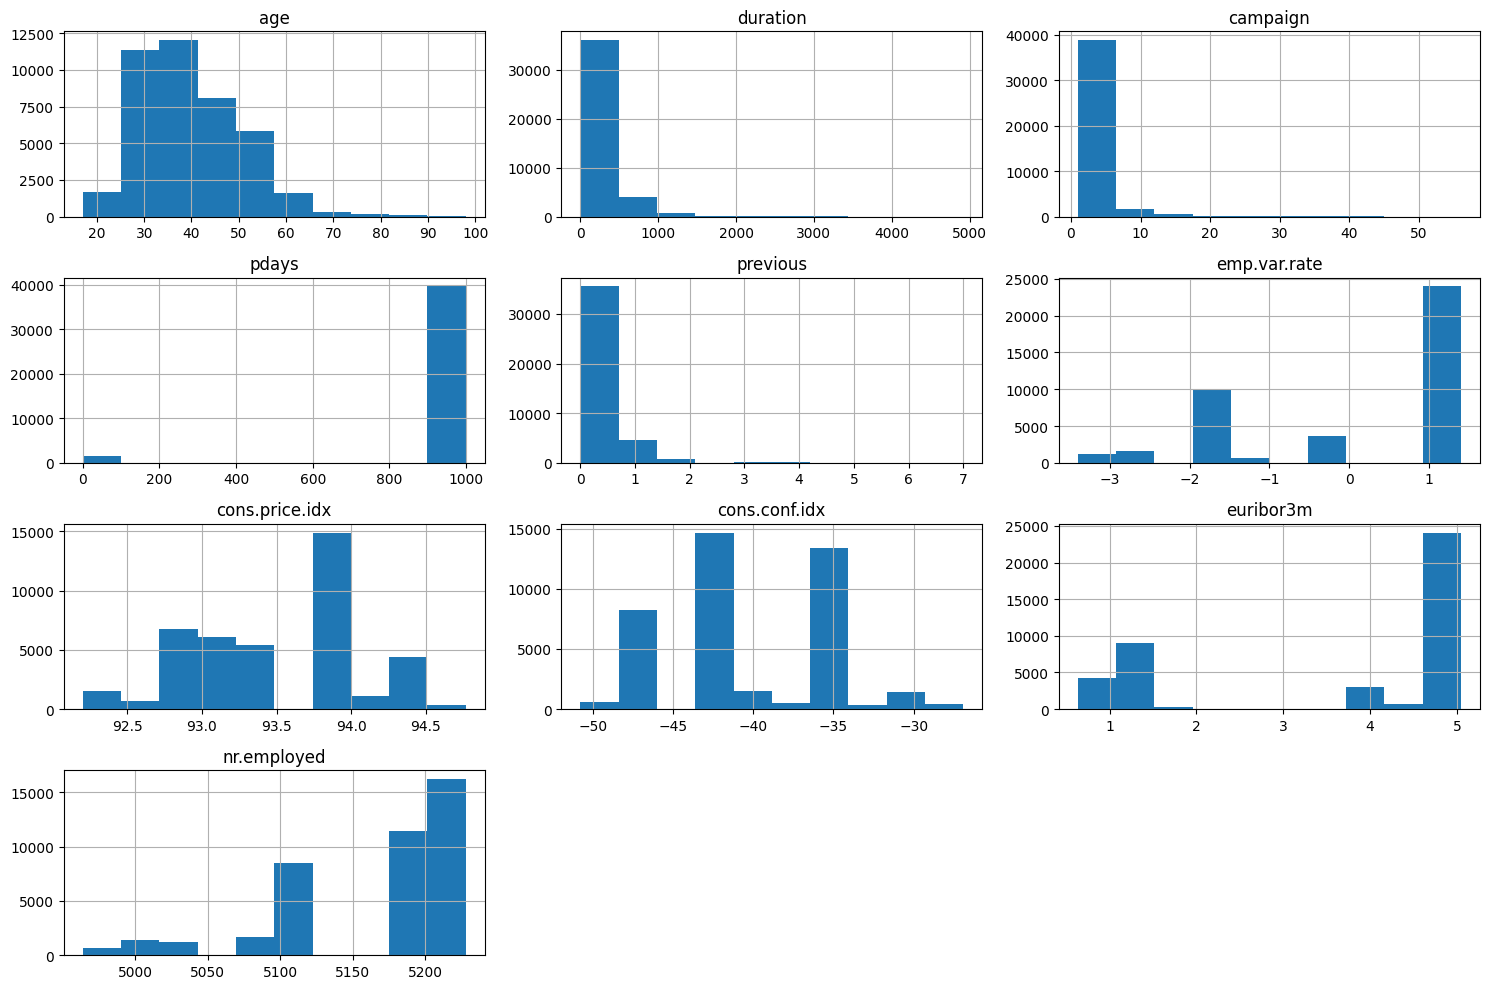

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

data[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()


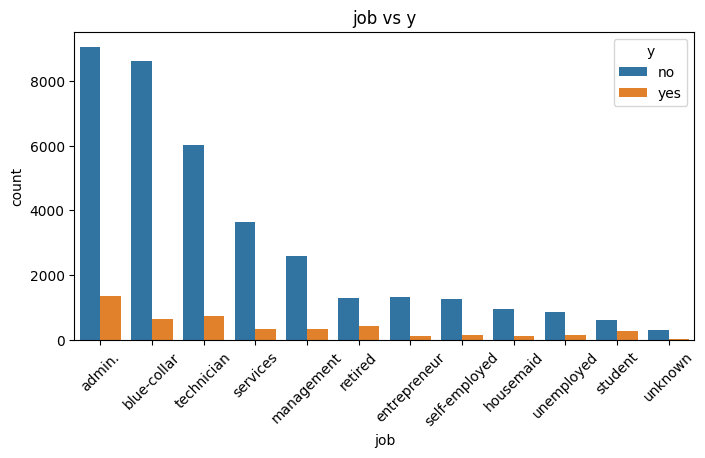

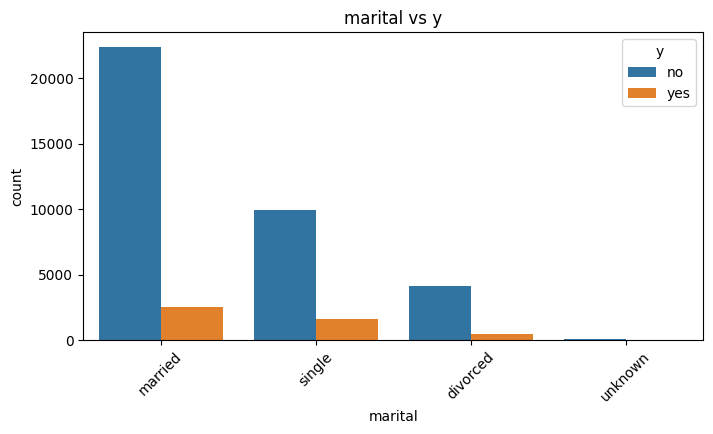

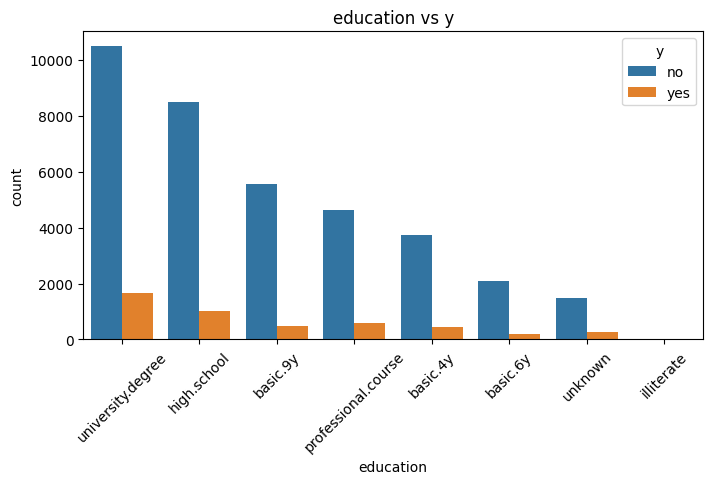

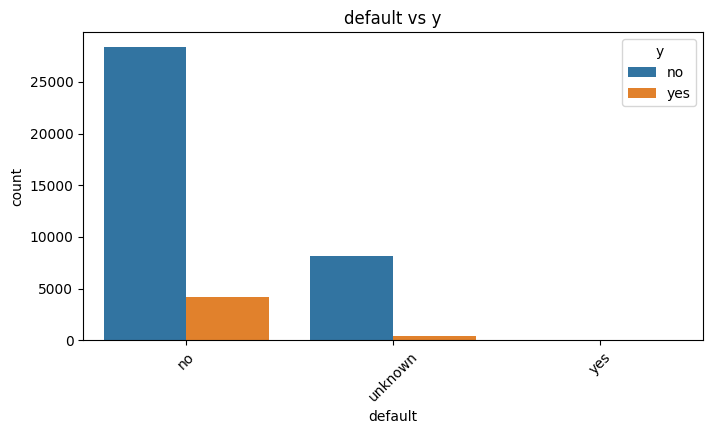

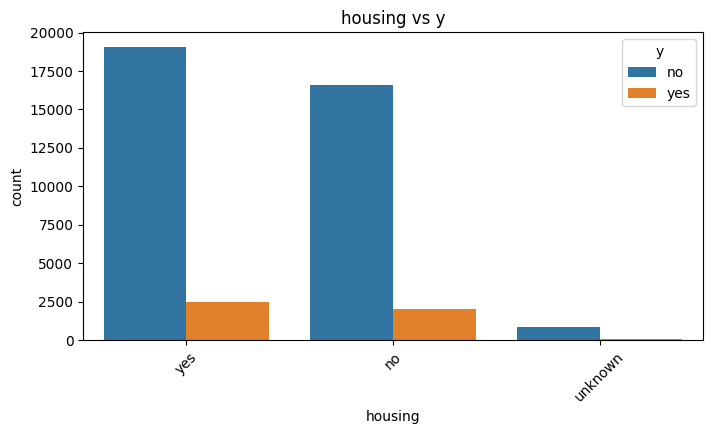

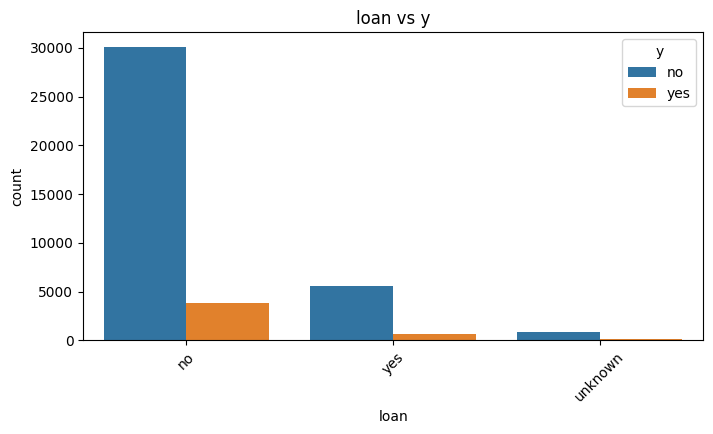

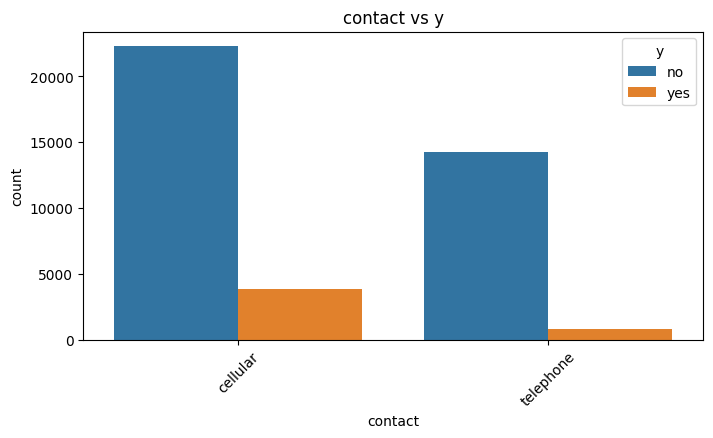

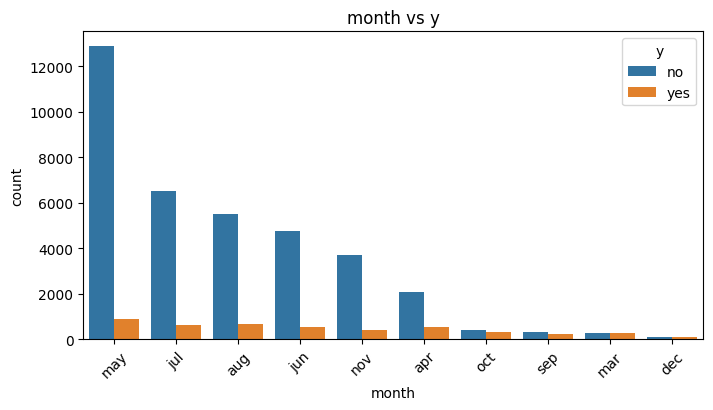

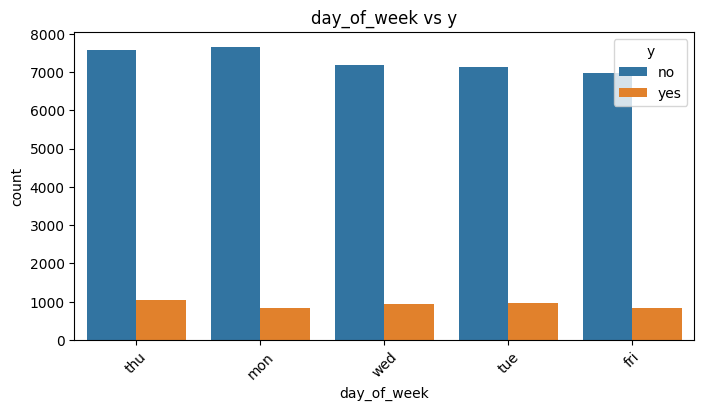

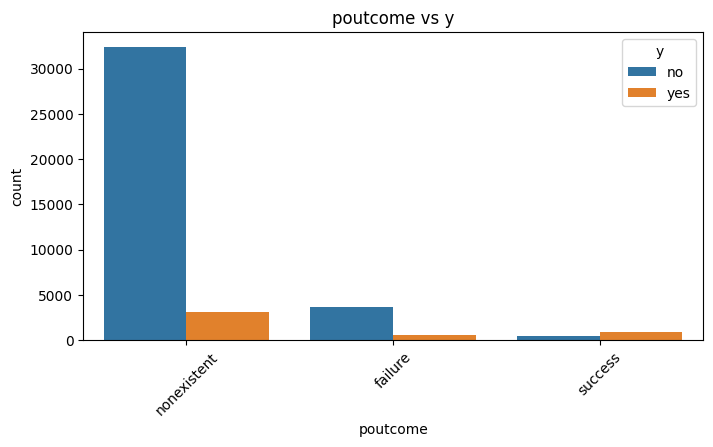

In [11]:
for col in cat_cols:
    if col != "y":
        plt.figure(figsize=(8, 4))
        sns.countplot(data=data, x=col, hue="y", order=data[col].value_counts().index)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs y")
        plt.show()


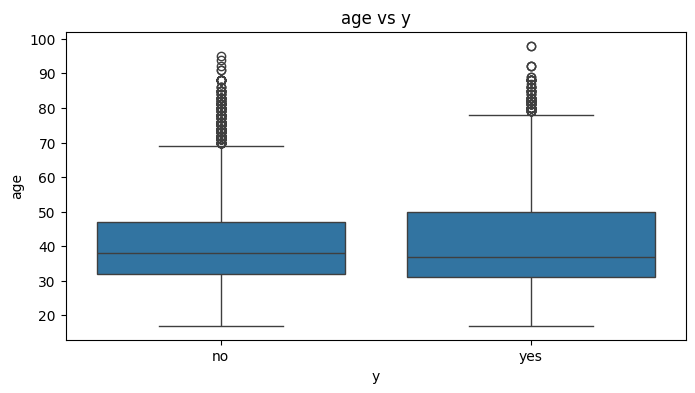

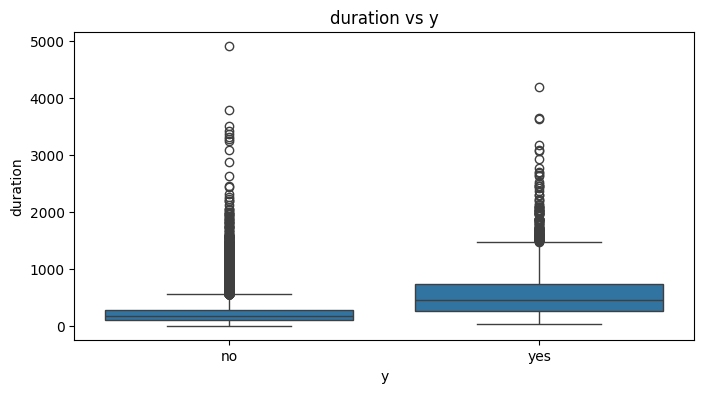

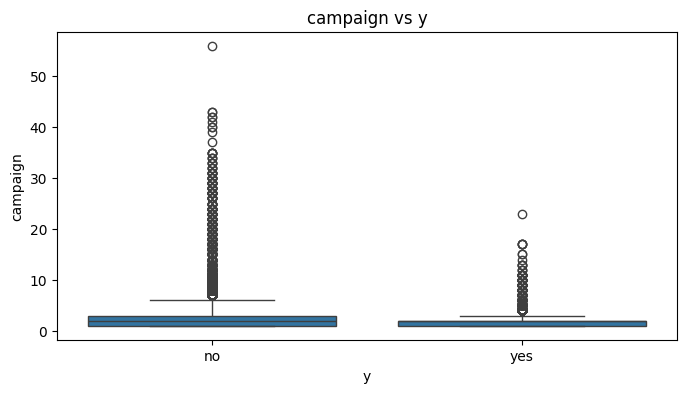

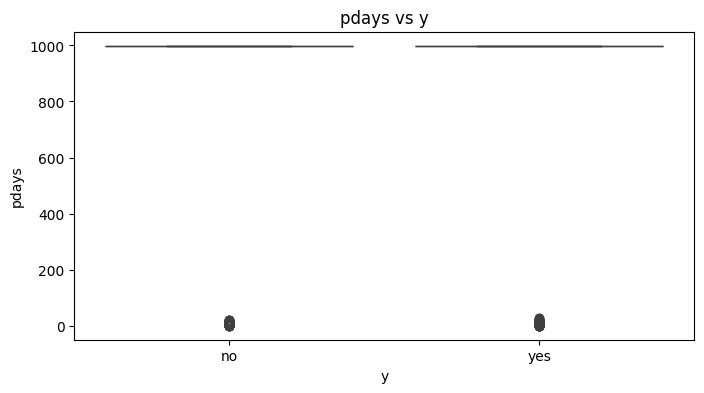

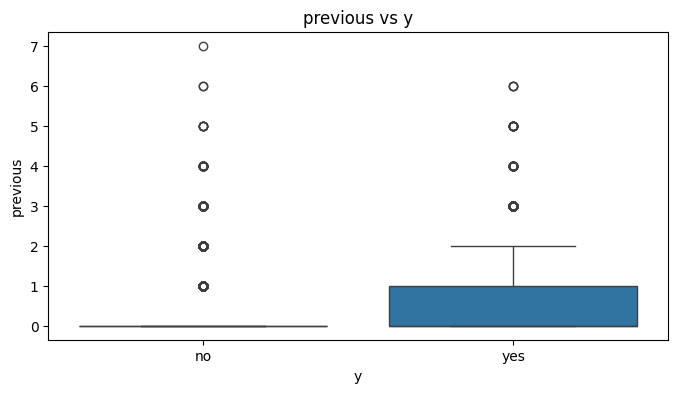

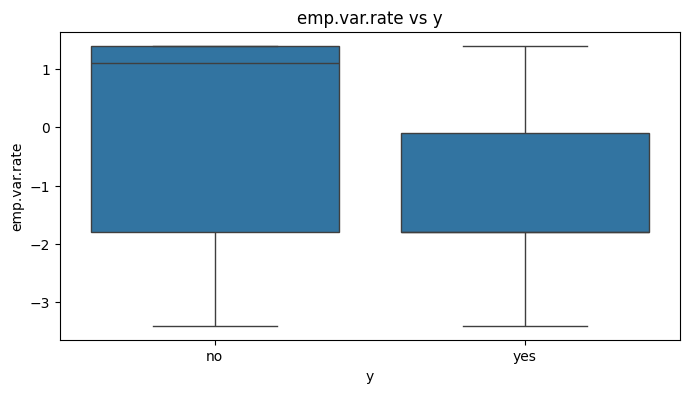

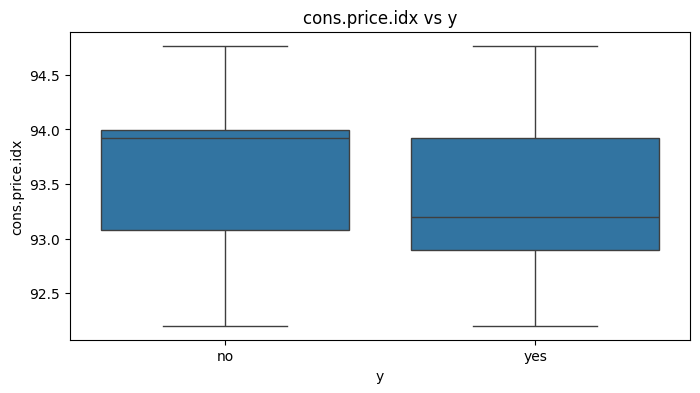

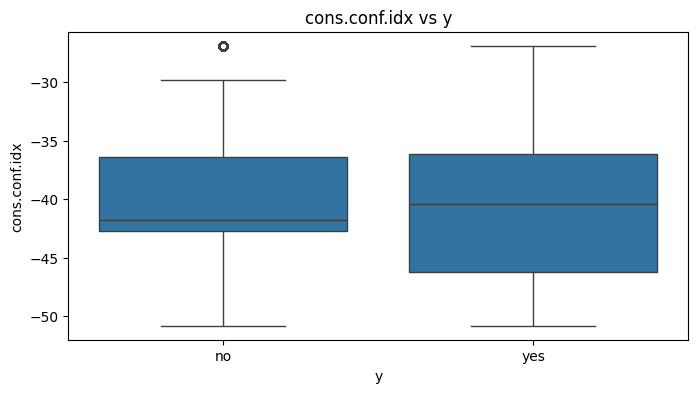

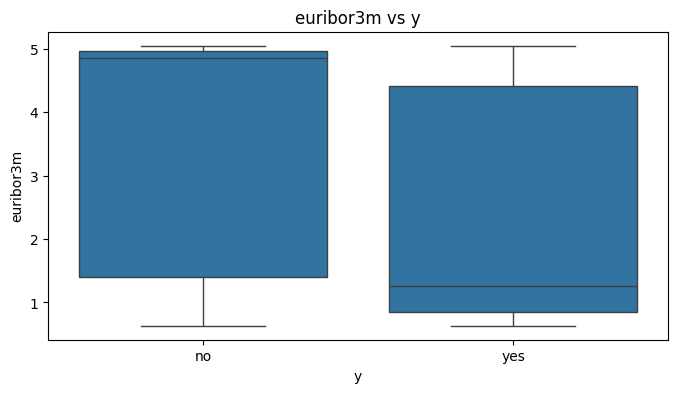

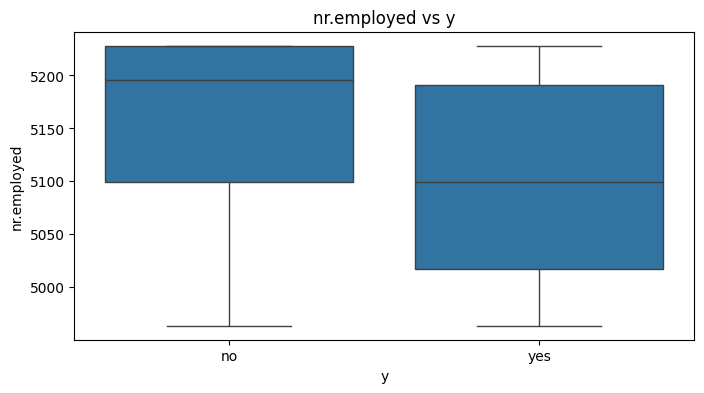

In [12]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, x="y", y=col)
    plt.title(f"{col} vs y")
    plt.show()


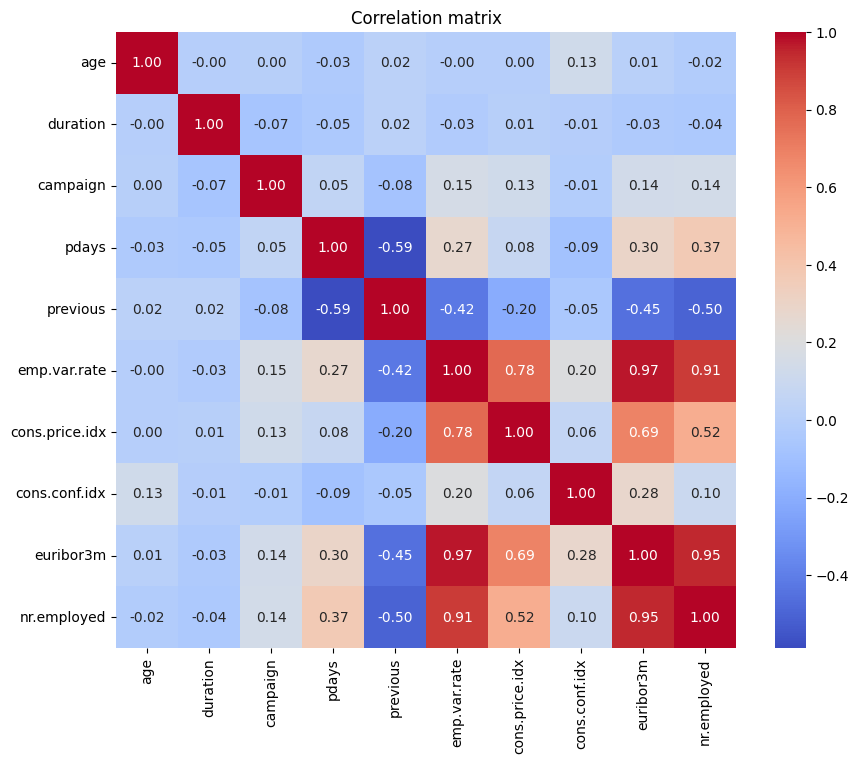

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()


## Conclusiones del EDA

- El dataset contiene 41176 registros y 21 variables luego de eliminar 12 duplicados.
- No se observaron valores nulos.
- La variable objetivo `y` está desbalanceada: la clase `no` representa la gran mayoría de los casos.
- Las variables numéricas muestran escalas diferentes, por lo que será conveniente escalarlas antes de entrenar la regresión logística.
- La variable `pdays` está fuertemente concentrada en 999, lo que sugiere que muchos clientes no habían sido contactados previamente.
- Algunas variables macroeconómicas pueden estar altamente correlacionadas entre sí, por lo que conviene revisar multicolinealidad.
- La variable `duration` parece muy informativa, aunque puede generar fuga de información si se quiere predecir antes de realizar la llamada.


In [14]:
X = data.drop("y", axis=1)
y = data["y"]

X.shape, y.shape


((41176, 20), (41176,))

In [15]:
y = y.map({"no": 0, "yes": 1})
y.head()


0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [16]:
X = pd.get_dummies(X, drop_first=True)
X.head()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((32940, 53), (8236, 53), (32940,), (8236,))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

selection_model = SelectKBest(chi2, k=5)
selection_model.fit(X_train_scaled, y_train)


In [ ]:
ix = selection_model.get_support()

X_train_sel = pd.DataFrame(X_train_scaled, columns=X_train.columns).iloc[:, ix]
X_test_sel = pd.DataFrame(X_test_scaled, columns=X_test.columns).iloc[:, ix]

X_train_sel.head()


In [ ]:
selected_features = X_train.columns[ix]
selected_features


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_sel, y_train)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test_sel)
y_prob = model.predict_proba(X_test_sel)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


In [ ]:
from sklearn.model_selection import GridSearchCV

hyperparams = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    hyperparams,
    scoring="accuracy",
    cv=5
)

grid.fit(X_train_sel, y_train)
grid.best_params_


In [ ]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_sel)
y_prob_best = best_model.predict_proba(X_test_sel)[:, 1]

print("Accuracy optimizado:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print("ROC-AUC optimizado:", roc_auc_score(y_test, y_prob_best))
